In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# **Importing Data**

In [2]:
train_set = pd.read_csv("/kaggle/input/playground-series-s6e2/train.csv")
test_set = pd.read_csv("/kaggle/input/playground-series-s6e2/test.csv")

In [3]:
# 1. Type out the exact features you want to train on
# selected_features = [
#     'Age', 'Sex', 'Chest pain type', 'BP', 'Cholesterol', 
#     'FBS over 120', 'EKG results', 'Max HR', 'Exercise angina', 
#     'ST depression', 'Slope of ST', 'Number of vessels fluro', 'Thallium'
# ]
X = train_set.iloc[:, :-1].values

y = train_set.iloc[: , -1].values

In [4]:
print(X)

[[0.00000e+00 5.80000e+01 1.00000e+00 ... 2.00000e+00 2.00000e+00
  7.00000e+00]
 [1.00000e+00 5.20000e+01 1.00000e+00 ... 1.00000e+00 0.00000e+00
  3.00000e+00]
 [2.00000e+00 5.60000e+01 0.00000e+00 ... 1.00000e+00 0.00000e+00
  3.00000e+00]
 ...
 [6.29997e+05 6.70000e+01 1.00000e+00 ... 1.00000e+00 2.00000e+00
  7.00000e+00]
 [6.29998e+05 5.20000e+01 1.00000e+00 ... 1.00000e+00 0.00000e+00
  6.00000e+00]
 [6.29999e+05 5.10000e+01 0.00000e+00 ... 1.00000e+00 0.00000e+00
  3.00000e+00]]


In [5]:
print(y)

['Presence' 'Absence' 'Absence' ... 'Presence' 'Presence' 'Absence']


# **Encoding the Independent Variable**

In [6]:
from sklearn.preprocessing import LabelEncoder #LabelEncoder (For the Output/Target)

le = LabelEncoder()
y = le.fit_transform(y)

In [7]:
print(y)

[1 0 0 ... 1 1 0]


# **Finding the Missing Values**

In [8]:
# Check missing values per column in NumPy
# axis=0 means "collapse the rows to sum up the columns"
                                            #Column Wise
missing_per_column = pd.isnull(X).sum(axis=0)

print("Missing values per column index:")
print(missing_per_column)

Missing values per column index:
[0 0 0 0 0 0 0 0 0 0 0 0 0 0]


# **Splitting the training set**

In [9]:
from sklearn.model_selection import train_test_split

                                                          #20% to the test/validation set 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state = 1)
                                                                         #"lock" the random shuffle

In [10]:
print(X_train)

[[1.99744e+05 5.70000e+01 1.00000e+00 ... 1.00000e+00 0.00000e+00
  7.00000e+00]
 [3.02200e+04 5.70000e+01 1.00000e+00 ... 1.00000e+00 0.00000e+00
  7.00000e+00]
 [4.72045e+05 6.40000e+01 1.00000e+00 ... 1.00000e+00 0.00000e+00
  3.00000e+00]
 ...
 [4.70924e+05 6.60000e+01 0.00000e+00 ... 1.00000e+00 0.00000e+00
  3.00000e+00]
 [4.91755e+05 6.60000e+01 1.00000e+00 ... 2.00000e+00 0.00000e+00
  3.00000e+00]
 [1.28037e+05 5.20000e+01 1.00000e+00 ... 2.00000e+00 2.00000e+00
  7.00000e+00]]


In [11]:
print(y_train)

[1 1 1 ... 0 0 1]


# **Visualizing the Feature Distribution**

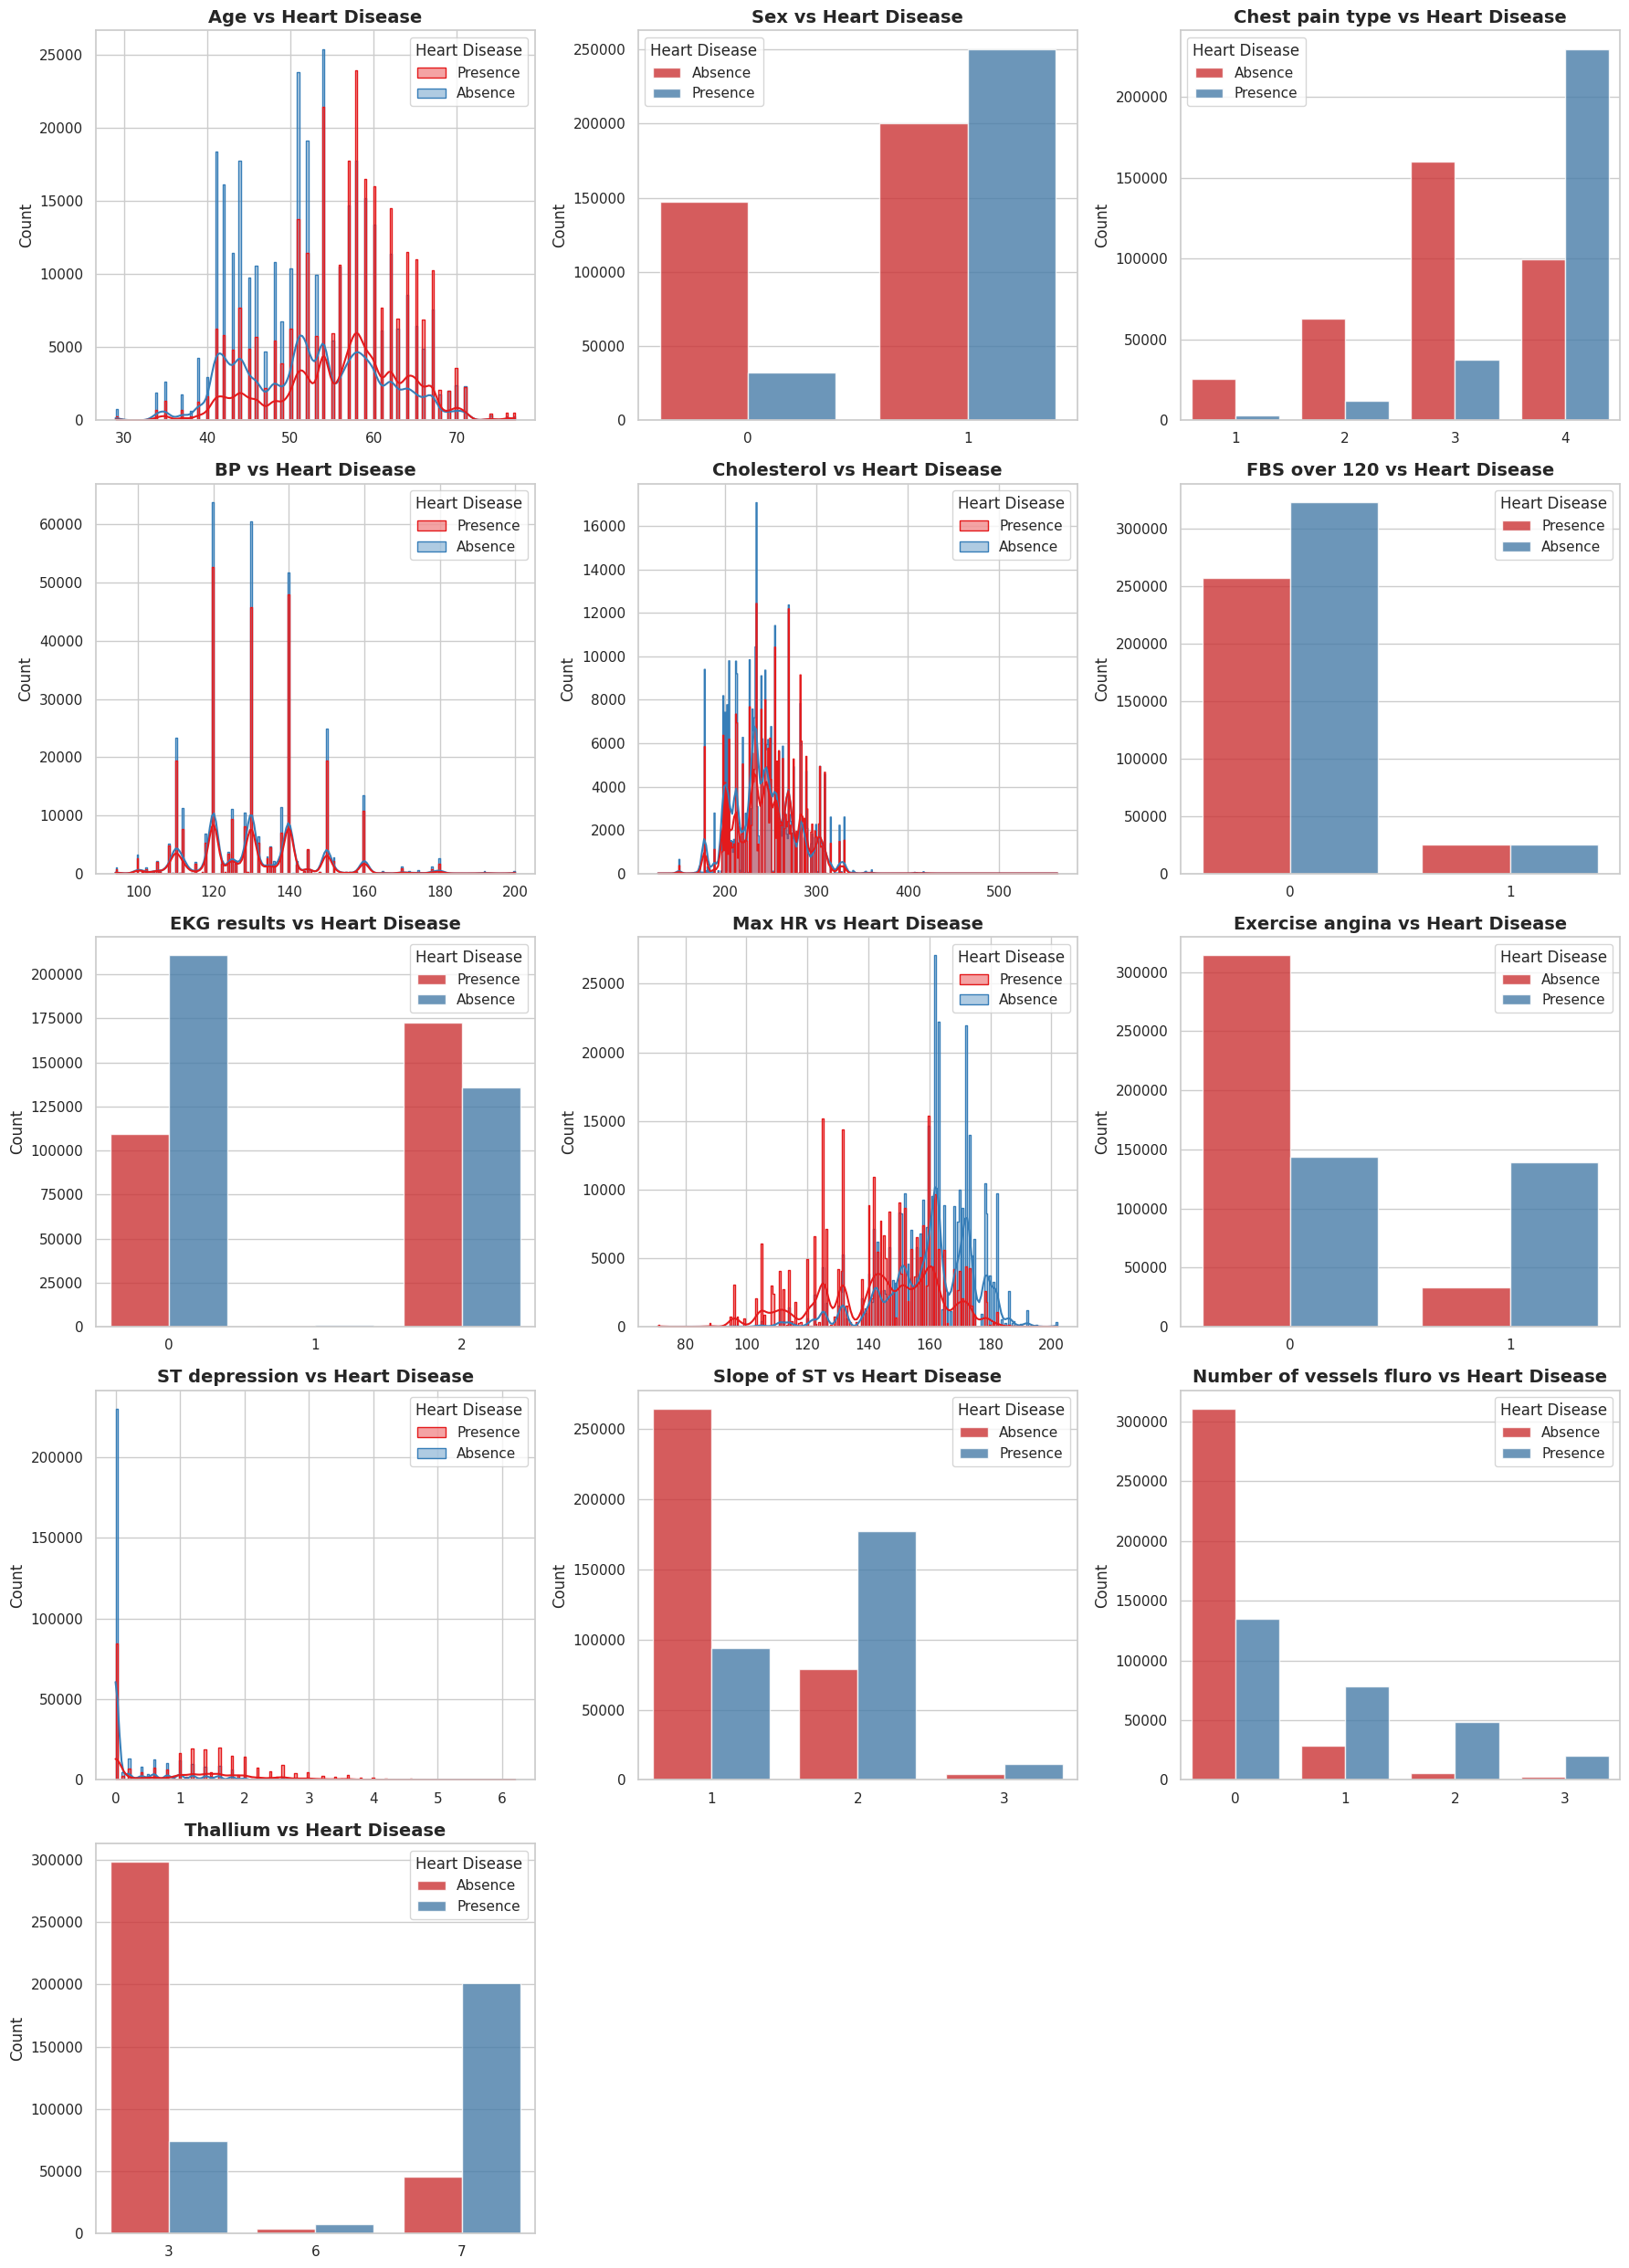

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

# 1. Get the list of features (ignoring 'id' and the target)
features_to_plot = [col for col in train_set.columns if col not in ['id', 'Heart Disease']]

# 2. Calculate the grid size for our subplots (3 columns wide)
n_features = len(features_to_plot)
cols = 3
rows = math.ceil(n_features / cols)

# 3. Create the figure canvas
plt.figure(figsize=(18, 5 * rows))
sns.set_theme(style="whitegrid") # Adds a nice clean background

# 4. Loop through features and plot distributions split by the target
for i, feature in enumerate(features_to_plot, 1):
    plt.subplot(rows, cols, i)
    
    # Check if the feature has many unique values (continuous) or few (categorical)
    if train_set[feature].nunique() > 10:
        # For continuous data like Age or Cholesterol, use a histogram with a density curve
        sns.histplot(
            data=train_set, 
            x=feature, 
            hue='Heart Disease', 
            kde=True,        
            element='step',  
            palette='Set1',
            alpha=0.4
        )
    else:
        # For categorical data like Sex or Chest pain type, use a count plot
        sns.countplot(
            data=train_set,
            x=feature,
            hue='Heart Disease',
            palette='Set1',
            alpha=0.8
        )
        
    plt.title(f'{feature} vs Heart Disease', fontsize=14, fontweight='bold')
    plt.xlabel('')
    plt.ylabel('Count')

plt.tight_layout()
plt.show()

# **Identifying the Co-Relations**

In [13]:
# 1. Make a copy so we don't alter your original dataset
df_scores = train_set.drop(columns=['id']).copy()

# 2. Convert target to numeric (1 for Presence, 0 for Absence)
if df_scores['Heart Disease'].dtype == 'object':
    df_scores['Heart Disease'] = df_scores['Heart Disease'].map({'Absence': 0, 'Presence': 1})

# 3. Calculate correlations and sort them from highest to lowest
correlations = df_scores.corr()['Heart Disease'].sort_values(ascending=False)

print("Correlation Scores with Heart Disease:\n")
print(correlations)

Correlation Scores with Heart Disease:

Heart Disease              1.000000
Thallium                   0.605776
Chest pain type            0.460684
Exercise angina            0.441864
Number of vessels fluro    0.438604
ST depression              0.430641
Slope of ST                0.415050
Sex                        0.342446
EKG results                0.218961
Age                        0.212091
Cholesterol                0.082753
FBS over 120               0.033570
BP                        -0.005181
Max HR                    -0.440985
Name: Heart Disease, dtype: float64


# **Train the Model With Combined Models**

In [14]:
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostClassifier
from sklearn.metrics import roc_auc_score

# 1. Remove the 'id' column (which is at index 0)
X_train_clean = X_train[:, 1:]
X_val_clean = X_test[:, 1:] # Note: X_test is your validation set

print(f"Cleaned X_train shape: {X_train_clean.shape}")

# ==========================================
# MODEL 1: XGBOOST
# ==========================================
print("\n--- Training XGBoost ---")
xgb_model = xgb.XGBClassifier(
    n_estimators=350,
    learning_rate=0.05,
    max_depth=7,
    eval_metric='auc',
    random_state=423
)
xgb_model.fit(X_train_clean, y_train)
xgb_val_probs = xgb_model.predict_proba(X_val_clean)[:, 1]

# ==========================================
# MODEL 2: LIGHTGBM
# ==========================================
print("--- Training LightGBM ---")
lgb_model = lgb.LGBMClassifier(
    n_estimators=350,
    learning_rate=0.05,
    max_depth=7,
    random_state=423,
    verbose=-1 # Keeps the output clean
)
lgb_model.fit(X_train_clean, y_train)
lgb_val_probs = lgb_model.predict_proba(X_val_clean)[:, 1]

# ==========================================
# MODEL 3: CATBOOST
# ==========================================
print("--- Training CatBoost ---")
cat_model = CatBoostClassifier(
    iterations=350,
    learning_rate=0.05,
    depth=7,
    eval_metric='AUC',
    random_seed=423,
    verbose=0 # verbose=0 stops it from printing 350 lines of output
)
cat_model.fit(X_train_clean, y_train)
cat_val_probs = cat_model.predict_proba(X_val_clean)[:, 1]

# ==========================================
# 4. BLENDING (THE MAGIC STEP)
# ==========================================
# We simply add the probabilities together and divide by 3 to get the average
blended_val_probs = (xgb_val_probs + lgb_val_probs + cat_val_probs) / 3

# ==========================================
# 5. EVALUATION
# ==========================================
print("\n=== FINAL ROC-AUC SCORES ===")
print(f"XGBoost Alone:  {roc_auc_score(y_test, xgb_val_probs):.5f}")
print(f"LightGBM Alone: {roc_auc_score(y_test, lgb_val_probs):.5f}")
print(f"CatBoost Alone: {roc_auc_score(y_test, cat_val_probs):.5f}")
print(f"BLENDED ENSEMBLE: {roc_auc_score(y_test, blended_val_probs):.5f}")

Cleaned X_train shape: (504000, 13)

--- Training XGBoost ---
--- Training LightGBM ---


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


--- Training CatBoost ---

=== FINAL ROC-AUC SCORES ===
XGBoost Alone:  0.95480
LightGBM Alone: 0.95494
CatBoost Alone: 0.95484
BLENDED ENSEMBLE: 0.95500


# **Saving the Model**

In [15]:
import pandas as pd

# 1. Prepare the Kaggle test set
# Extract the IDs for the final file
test_ids = test_set['id']

# Drop the 'id' column to match how we trained the models, and convert to a NumPy array
X_test_kaggle = test_set.drop(columns=['id']).values

print(f"Kaggle test features shape: {X_test_kaggle.shape}")

# 2. Generate predictions from all three models
print("Generating XGBoost predictions...")
xgb_test_preds = xgb_model.predict_proba(X_test_kaggle)[:, 1]

print("Generating LightGBM predictions...")
lgb_test_preds = lgb_model.predict_proba(X_test_kaggle)[:, 1]

print("Generating CatBoost predictions...")
cat_test_preds = cat_model.predict_proba(X_test_kaggle)[:, 1]

# 3. Blend the predictions! (Average them together)
print("Blending predictions...")
# Instead of dividing by 3, we multiply by percentages that add up to 1.0 (100%)
# Let's give LGBM and CatBoost 40% each, and XGBoost 20%
final_blended_preds = (xgb_test_preds * 0.40) + (lgb_test_preds * 0.40) + (cat_test_preds * 0.20)

# 4. Create the final Kaggle submission DataFrame
submission = pd.DataFrame({
    'id': test_ids,
    'Heart Disease': final_blended_preds
})

# 5. Save to CSV (index=False is strictly required)
submission.to_csv('submission_blended.csv', index=False)
print("\nSuccess! 'submission_blended.csv' is ready for upload!")

Kaggle test features shape: (270000, 13)
Generating XGBoost predictions...
Generating LightGBM predictions...


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Generating CatBoost predictions...
Blending predictions...

Success! 'submission_blended.csv' is ready for upload!


# **Single Model Training**

In [16]:
import xgboost as xgb
from sklearn.metrics import roc_auc_score

# 1. Remove the 'id' column (which is at index 0) from your NumPy arrays
# The syntax [:, 1:] means "take all rows, and take columns from index 1 to the end"
X_train_clean = X_train[:, 1:]
X_val_clean = X_test[:, 1:] # Note: your X_test variable is actually your validation set

print(f"Original X_train shape: {X_train.shape}")
print(f"Cleaned X_train shape: {X_train_clean.shape} (id column removed)\n")

# 2. Initialize the XGBoost Classifier
# We set eval_metric to 'auc' since that is our target Kaggle metric
xgb_model = xgb.XGBClassifier(
    n_estimators=350,
    learning_rate=0.05,
    max_depth=7,
    eval_metric='auc',
    random_state=423
)

# 3. Train the model
print("Training the XGBoost model...")
xgb_model.fit(X_train_clean, y_train)
print("Training complete!\n")

# 4. Generate probability predictions on your validation set
# We use predict_proba() and take the second column [:, 1] to get the probability of 'Presence' (1)
y_val_probs = xgb_model.predict_proba(X_val_clean)[:, 1]

# 5. Calculate and print the ROC-AUC score
auc_score = roc_auc_score(y_test, y_val_probs)
print(f"Validation ROC-AUC Score: {auc_score:.4f}")

Original X_train shape: (504000, 14)
Cleaned X_train shape: (504000, 13) (id column removed)

Training the XGBoost model...
Training complete!

Validation ROC-AUC Score: 0.9548


# **Saving the Submission File**

In [17]:
import pandas as pd

# 1. Extract the 'id' column from the Kaggle test set for our final file
test_ids = test_set['id']

# 2. Prepare the test features
# We drop the 'id' column and convert it to a NumPy array to perfectly match X_train_clean
X_test_final = test_set.drop(columns=['id']).values

print(f"Final test features shape: {X_test_final.shape}")

# 3. Generate probability predictions on the official Kaggle test set
print("Generating predictions...")
final_probabilities = xgb_model.predict_proba(X_test_final)[:, 1]

# 4. Create the Kaggle submission DataFrame
submission = pd.DataFrame({
    'id': test_ids,
    'Heart Disease': final_probabilities
})

# 5. Save to CSV (index=False is strictly required!)
submission.to_csv('submission2.csv', index=False)
print("submission.csv successfully created and ready for upload!")

Final test features shape: (270000, 13)
Generating predictions...
submission.csv successfully created and ready for upload!
